<strong><center><h1> DBSCAN

In [1]:
import pandas as pd
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import numpy as np

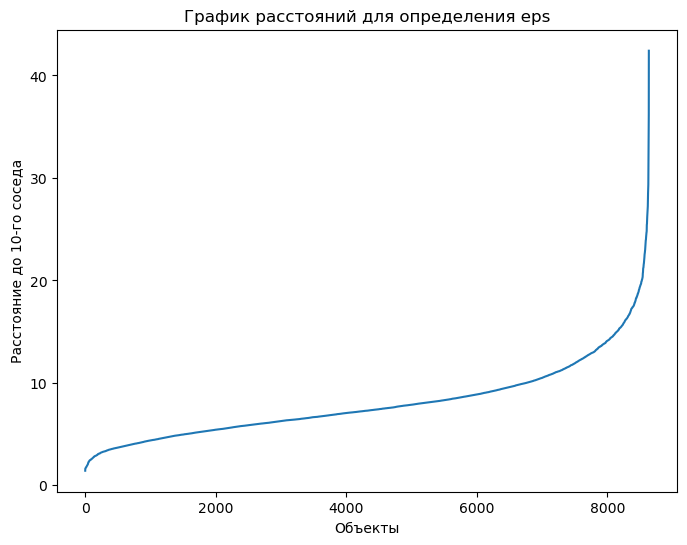

In [3]:
data_path = '../../../../data/processed_data/main_datasets/data_with_generated_features.csv'
data = pd.read_csv(data_path)

X = data.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

neighbors = NearestNeighbors(n_neighbors=10)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, -1])
plt.figure(figsize=(8, 6))
plt.plot(distances)
plt.title('График расстояний для определения eps')
plt.xlabel('Объекты')
plt.ylabel('Расстояние до 10-го соседа')
plt.show()

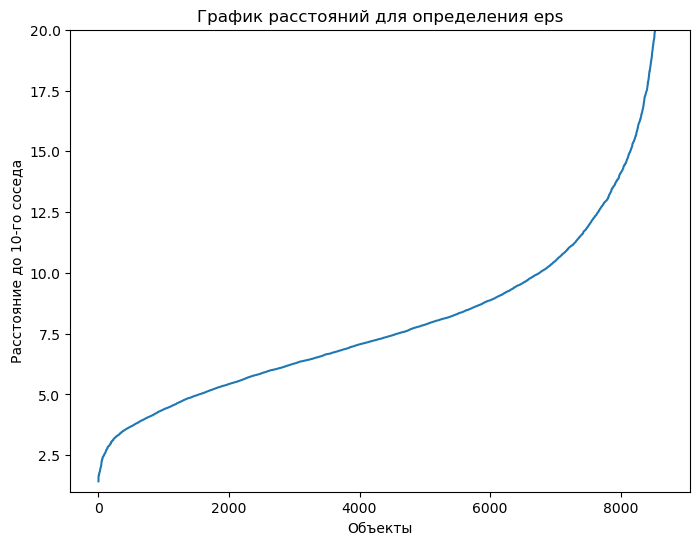

In [5]:
plt.figure(figsize=(8, 6))
plt.plot(distances)
plt.ylim(1, 20) 
plt.title('График расстояний для определения eps')
plt.xlabel('Объекты')
plt.ylabel('Расстояние до 10-го соседа')
plt.show()

In [6]:
eps = 11  
min_samples = 50  

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan.fit(X_scaled)

data['Cluster'] = dbscan.labels_

In [7]:
output_path = '../../../../data/processed_data/train_models_data/data_without_PCA/data_with_generated_features/DBSCAN_generated_features.csv'
data.to_csv(output_path, index=False)